# EDA Pasca-Preprocessing (Verifikasi)

Notebook ini adalah eda kedua yang berjalan SETELAH preprocessing. Tujuannya
bukan mengulang analisis, tapi memverifikasi bahwa keputusan desain di
src/preprocessing.py tidak menghilangkan sinyal yang penting, serta
menyiapkan beberapa angka yang dibutuhkan saat modeling.

Sumber data: data/processed/train_preprocessed.jsonl (dan val/test hanya
untuk cek panjang teks per split).

Yang diverifikasi:
1. fitur struktural tersimpan (caps_ratio, n_elongated, n_hashtag, n_emoji)
   masih membedakan toxic vs non-toxic
2. kosakata setelah cleaning masih masuk akal
3. panjang TEXT_ACLEAN untuk keputusan max_length
4. distribusi n_slang_replaced + contoh mapping terbanyak
5. checklist anomali (teks kosong, teks menyusut drastis, dsb)

Ganti variabel data dan folder_gambar di sel pertama sesuai komputer.

In [1]:
# Yang perlu diganti hanya 2 baris di bawah ini.
# data: folder data processed (berisi *_preprocessed.jsonl)
# folder_gambar: tempat nyimpan gambar

data = r'C:\SEMESTER 5\Project Sistem Cerdas\Projek\data\processed'
folder_gambar = r'C:\SEMESTER 5\Project Sistem Cerdas\Projek\reports\figures'

# Kode di bawah tidak perlu diubah
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

if not os.path.isdir(data):
    raise FileNotFoundError('Folder tidak ketemu: ' + data + '. Cek variabel data di atas.')

np.random.seed(42)
LABEL_COLS = ['toxicity', 'profanity_obscenity', 'threat_incitement_to_violence',
              'insults', 'identity_attack', 'sexually_explicit']
FIG_DIR = folder_gambar
os.makedirs(FIG_DIR, exist_ok=True)

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', palette='deep')
    print('seaborn terpakai')
except ImportError:
    print('seaborn belum diinstall, pakai tampilan matplotlib biasa')

plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'


def load_jsonl(p):
    with open(p, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]


df = pd.DataFrame(load_jsonl(os.path.join(data, 'train_preprocessed.jsonl')))
# buang baris tanpa text_clean (seharusnya tidak ada)
kosong = df['text_clean'].isna().sum()
if kosong:
    print('peringatan: ada', kosong, 'baris text_clean kosong (dibuang)')
df = df[df['text_clean'].notna()].reset_index(drop=True)

print('Data pasca-preprocessing berhasil dimuat:', len(df), 'teks')
print('Kolom fitur tersedia :', sorted(df['fitur'].iloc[0].keys()))

seaborn terpakai


Data pasca-preprocessing berhasil dimuat: 19986 teks
Kolom fitur tersedia : ['caps_ratio', 'n_allcaps_word', 'n_char', 'n_elongated', 'n_emoji', 'n_hashtag', 'n_mention', 'n_slang_replaced', 'n_url', 'n_word']


## 1. Sinyal fitur struktural masih ada?

Preprocessing memindahkan sinyal kapital dan huruf berulang ke kolom `fitur`.
Kalau keputusan desainnya benar, fitur ini tetap membedakan teks toxic dan
non-toxic seperti yang dulu terlihat di EDA 1 (pada teks mentah).

Rata-rata nilai fitur per kelompok:
          caps_ratio  n_elongated  n_hashtag  n_emoji
toxicity                                             
0              0.136        0.221      1.475    0.793
1              0.156        0.339      0.959    0.972

% teks yang memuat fitur (>0):
          caps_ratio  n_elongated  n_hashtag  n_emoji
toxicity                                             
0               90.8         13.4       26.8     21.2
1               93.9         20.1       20.3     22.5


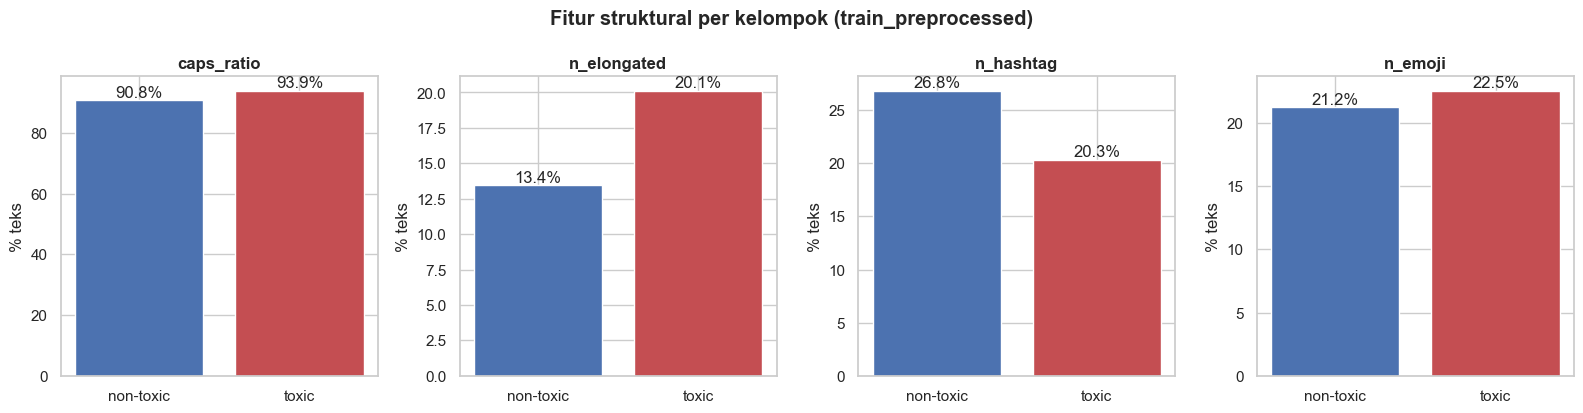

In [2]:
fit = pd.DataFrame(df['fitur'].tolist())
fit['toxicity'] = df['toxicity'].values

pilihan = ['caps_ratio', 'n_elongated', 'n_hashtag', 'n_emoji']
rata = fit.groupby('toxicity')[pilihan].mean()
pernah = fit.groupby('toxicity').apply(lambda g: pd.Series(
    {k: (g[k] > 0).mean() for k in pilihan}))

print('Rata-rata nilai fitur per kelompok:')
print(rata.round(3).to_string())
print()
print('% teks yang memuat fitur (>0):')
print((pernah * 100).round(1).to_string())

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, nama in zip(axes, pilihan):
    vals = pernah[nama] * 100
    bars = ax.bar(['non-toxic', 'toxic'], vals, color=['#4c72b0', '#c44e52'])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, '{:.1f}%'.format(v),
                ha='center', va='bottom')
    ax.set_title(nama, fontsize=12)
    ax.set_ylabel('% teks')
fig.suptitle('Fitur struktural per kelompok (train_preprocessed)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '17_fitur_per_label.png'), dpi=150, bbox_inches='tight')
plt.show()

**Kesimpulan bagian 1:**

Bandingkan kolom % memuat fitur di tabel pertama dengan EDA 1 yang berbasis
teks mentah (kapital, huruf berulang, emoji, hashtag). Polanya harus tetap
terlihat pada data preprocessed - ini bukti sinyal tidak hilang, hanya pindah
tempat dari dalam teks ke kolom fitur. Kalau ada fitur yang selisihnya menyempit
drastis dibanding EDA 1, berarti ada aturan pembersihan yang kebablasan.

## 2. Kosakata setelah cleaning

Tokenizer akan menerima `text_clean`. Di sini kata dan bigram terpopuler dihitung
ulang dari teks hasil cleaning, lalu dibandingkan toxic vs non-toxic. Harapannya
pola EDA 1 tetap muncul - bedanya sekarang "zionis israel" (misal) ditulis dalam
ejaan yang lebih konsisten, dan kata slang sudah dinormalkan.

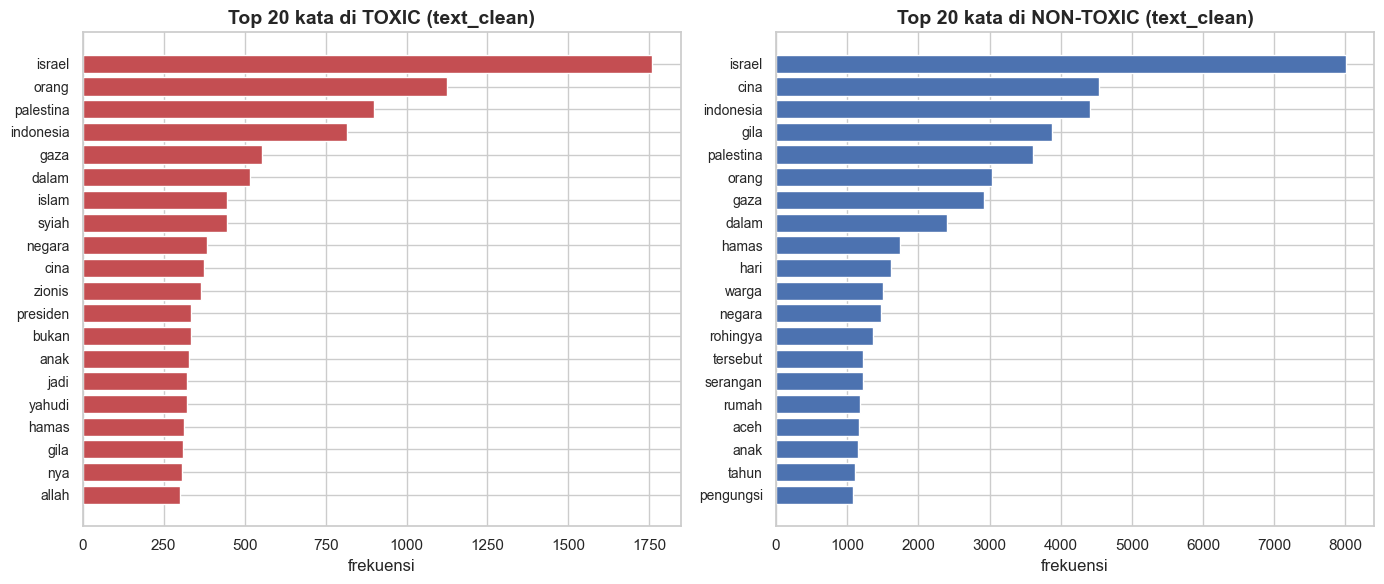

Kata slang mentah yang masih muncul di top-30 toxic: tidak ada


In [3]:
STOP = set("""yang dan di ke dari ini itu dengan untuk tidak ya aku saya kamu dia mereka kita kami
ada adalah akan sudah belum juga hanya saja lebih oleh pada atau jika kalau karena tapi tetapi
bisa mau gue gua gw lo lu udah dah banget bgt sih dong deh kok nih tuh emang memang saat
sama apa kenapa gimana kaya kayak begini begitu gitu tidak ngga gak ga
the a in of and is it to you my me""".split())


def tokenize(s):
    return [w for w in re.findall(r"[a-zA-Z][a-zA-Z']+", s.lower())
            if w not in STOP and len(w) > 2]


uni_tox, uni_non = Counter(), Counter()
for t, y in zip(df['text_clean'], df['toxicity']):
    toks = tokenize(t)
    (uni_tox if y == 1 else uni_non).update(toks)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cnt, judul, warna in [(axes[0], uni_tox, 'Top 20 kata di TOXIC (text_clean)', '#c44e52'),
                              (axes[1], uni_non, 'Top 20 kata di NON-TOXIC (text_clean)', '#4c72b0')]:
    kata, nilai = zip(*cnt.most_common(20))
    pos = range(len(kata))[::-1]
    ax.barh(list(pos), list(nilai), color=warna)
    ax.set_yticks(list(pos))
    ax.set_yticklabels(kata, fontsize=10)
    ax.set_xlabel('frekuensi')
    ax.set_title(judul)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '18_kosakata_setelah_cleaning.png'), dpi=150, bbox_inches='tight')
plt.show()

# cek apakah kata slang mentah yang tidak ada di kamus masih tersisa di text_clean
sisa = [w for w, n in uni_tox.most_common(30) if re.match(r'^bgt$|^yg$|^ga$|^ngk$', w)]
print('Kata slang mentah yang masih muncul di top-30 toxic:', sisa if sisa else 'tidak ada')

**Kesimpulan bagian 2:**

Kata dan bigram yang muncul setelah cleaning seharusnya mirip polanya dengan
EDA 1 (kosakata identitas kelompok mendominasi toxic) tetapi dengan ejaan yang
jauh lebih rapi. Ini penting untuk tokenizer: kata yang sama tidak lagi tercerai
karena variasinya (misal "gk/gak/nggak/ngga" jadi konsisten). Kalau masih
banyak slang mentah yang lolos ke tabel ini, artinya cakupan kamus kurang -
boleh dicatat untuk perbaikan kamus berikutnya.

## 3. Panjang teks untuk keputusan max_length

Tokenizer akan beroperasi pada text_clean, jadi rekomendasi max_length
sebaiknya dihitung dari sini, bukan dari teks asli. Cleaning bisa mengubah
panjang: slang yang diperpanjang (bgt menjadi banget) menambah kata,
sementara penghapusan URL dan mention memangkas kata.

Statistik jumlah kata - text asli vs text_clean:
       text asli  text_clean
count    19986.0     19986.0
mean        37.3        37.7
std         60.2        60.9
min          1.0         1.0
25%         11.0        11.0
50%         20.0        21.0
75%         36.0        36.0
max        880.0       880.0

Persentil text_clean (kata): p50=21 p90=80 p95=141 p99=304


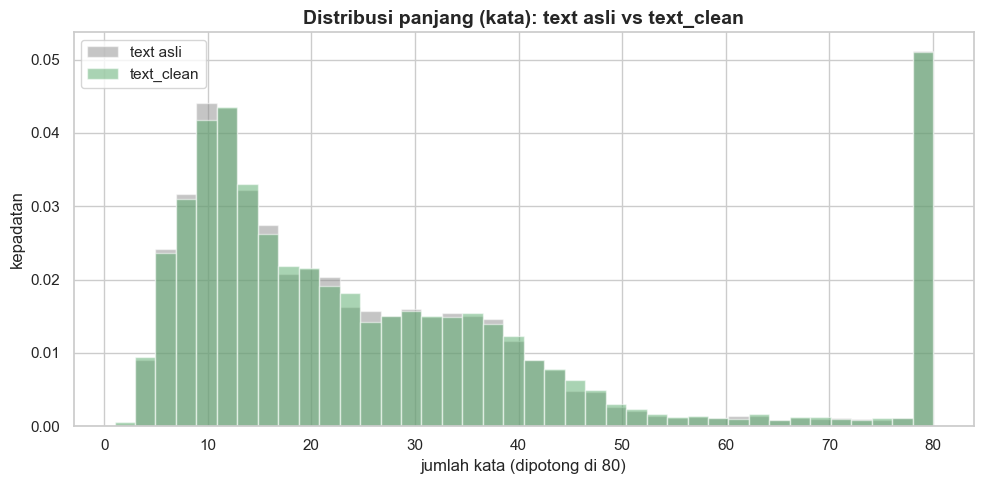


split train: p95=141 kata, p99=304 kata
split val: p95=230 kata, p99=457 kata


split test: p95=254 kata, p99=520 kata


In [4]:
df['n_word_asli'] = df['fitur'].apply(lambda f: f['n_word'])
df['n_word_clean'] = df['text_clean'].str.split().str.len()

print('Statistik jumlah kata - text asli vs text_clean:')
banding = pd.DataFrame({'text asli': df['n_word_asli'].describe().round(1),
                        'text_clean': df['n_word_clean'].describe().round(1)})
print(banding.to_string())
print()
print('Persentil text_clean (kata): p50={} p90={} p95={} p99={}'.format(
    int(df.n_word_clean.quantile(0.5)), int(df.n_word_clean.quantile(0.9)),
    int(df.n_word_clean.quantile(0.95)), int(df.n_word_clean.quantile(0.99))))

fig, ax = plt.subplots(figsize=(10, 5))
for kolom, warna, label in [('n_word_asli', '#8c8c8c', 'text asli'),
                            ('n_word_clean', '#55a868', 'text_clean')]:
    ax.hist(df[kolom].clip(0, 80), bins=40, alpha=0.5, density=True,
            label=label, color=warna)
ax.set_title('Distribusi panjang (kata): text asli vs text_clean')
ax.set_xlabel('jumlah kata (dipotong di 80)')
ax.set_ylabel('kepadatan')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '19_panjang_text_clean.png'), dpi=150, bbox_inches='tight')
plt.show()

print()
for nama in ['train', 'val', 'test']:
    if nama == 'train':
        d_ = df
    else:
        jalur = os.path.join(data, nama + '_preprocessed.jsonl')
        if not os.path.exists(jalur):
            continue
        d_ = pd.DataFrame(load_jsonl(jalur))
    panjang = d_['text_clean'].str.split().str.len()
    print('split {}: p95={} kata, p99={} kata'.format(
        nama, int(panjang.quantile(0.95)), int(panjang.quantile(0.99))))

**Kesimpulan bagian 3 (bahan PPT):**

Histogram text asli dan text_clean hampir menempel, artinya cleaning tidak
banyak mengubah panjang karena penambahan (slang diperpanjang) dan pengurangan
(mention serta URL dihapus) saling menetralkan. Persentil text_clean konsisten
di ketiga split.

Poin PPT:
- P95 dan P99 text_clean tetap meninggalkan sebagian teks di atas 128 token,
  jadi max_length 256 tetap dipakai
- Perkiraan kasar subword = 1,5 x jumlah kata, sehingga 256 token memberi
  ruang aman

## 4. Distribusi n_slang_replaced

Kolom n_slang_replaced mencatat berapa kata dalam satu teks yang diganti dengan
padanan kamus. Menjawab seberapa banyak teks yang benar-benar berubah, dan teks
mana yang paling banyak kena penggantian - teks ekstrem begitu enak dicermati
untuk menemukan mapping yang keliru.

Kategori jumlah kata slang yang diganti per teks:
fitur
0 kata      23.6
1-2 kata    39.4
3-5 kata    21.5
6+ kata     15.5


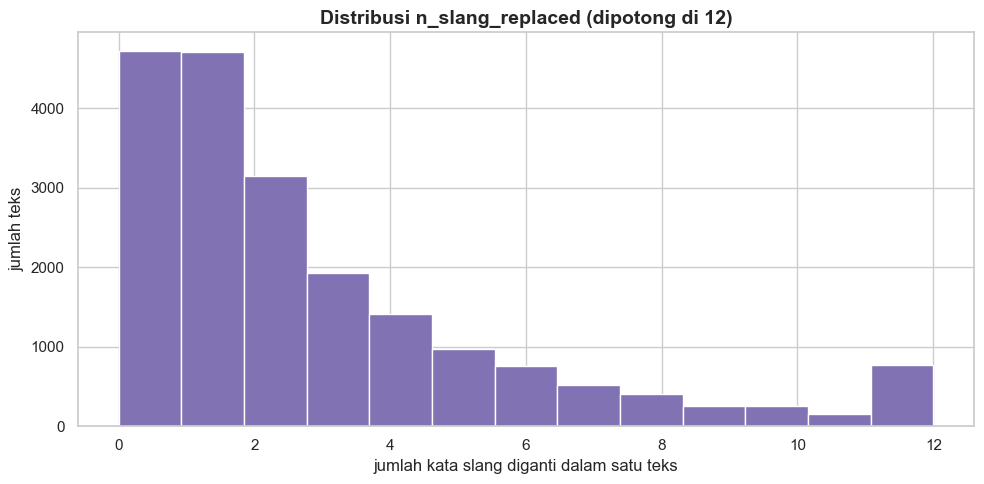


5 teks yang mengalami penggantian slang terbanyak:
  asli   : 'AUTO KRITIK KE RAKYAT Jadi ini adalah sebagian dari banyak nya poin poin keresah'
  bersih : 'auto kritik ke rakyat jadi ini adalah sebagian dari banyak nya poin poin keresah'
  n_ganti: 111

  asli   : 'NEW ARRIVAL\nCARGO PARASUT PANTS WANITA TALI SERUT\n.\nORIGINAL Produk BAGGU.OFFICI'
  bersih : 'new arrival cargo parasut pants wanita tali serut . original produk baggu.offici'
  n_ganti: 72

  asli   : 'MENTAL ILLNESS & POLITIK IDENTITAS\n\nRadikal far-left wing Amerika memang piawai '
  bersih : 'mental illness & politik identitas radikal far-left wing amerika memang piawai m'
  n_ganti: 60

  asli   : 'Ayo kita sambut anggota baru! Sar Rms, Akang Salafi, Aboll Aje, Alfiandhy Andhy,'
  bersih : 'ayo kita sambut anggota baru! sar rms, akang salafi, aboll saja alfiandhy andhy,'
  n_ganti: 59

  asli   : 'BERNIAT KULINERAN DI BOROBUDUR? CHINESEFOOD & SAMBEL GAMI 77 BISA JADI REKOMENDA'
  bersih : 'berniat kulineran di bor

In [5]:
slang = df['fitur'].apply(lambda f: f['n_slang_replaced'])

print('Kategori jumlah kata slang yang diganti per teks:')
kategori = pd.cut(slang, bins=[-0.5, 0.5, 2.5, 5.5, np.inf],
                  labels=['0 kata', '1-2 kata', '3-5 kata', '6+ kata'])
print((kategori.value_counts().sort_index() / len(slang) * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
slang.clip(0, 12).hist(bins=13, ax=ax, color='#8172b3')
ax.set_title('Distribusi n_slang_replaced (dipotong di 12)')
ax.set_xlabel('jumlah kata slang diganti dalam satu teks')
ax.set_ylabel('jumlah teks')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '20_distribusi_slang_replaced.png'), dpi=150, bbox_inches='tight')
plt.show()

print()
print('5 teks yang mengalami penggantian slang terbanyak:')
ganti = df['fitur'].apply(lambda f: f['n_slang_replaced'])
terbanyak = df.loc[ganti.nlargest(5).index]
for i, r in terbanyak.iterrows():
    print('  asli   :', repr(r['text'][:80]))
    print('  bersih :', repr(r['text_clean'][:80]))
    print('  n_ganti:', int(ganti[i]))
    print()

**Kesimpulan bagian 4 (bahan PPT):**

Sebagian besar teks hanya mengalami sedikit penggantian slang (1-2 kata),
dan hanya sebagian kecil yang diganti 6 kata atau lebih. Teks ekstrem itu
yang wajib dicek manual, karena di sinilah paling mudah muncul mapping yang
keliru (seperti kasus "HT" yang menjadi "hati").

Poin PPT:
- Penggantian slang membuat vocabulary lebih seragam, membantu tokenizer
- Namun porsi teks yang diganti 6+ kata tetap perlu diaudit untuk mencegah
  kerusakan konteks
- Ini alasan text asli tetap disimpan di file preprocessed

## 5. Checklist anomali

Cleaning yang agresif berisiko menghilangkan teks sama sekali (misal saat
isinya hanya URL atau mention), atau menyusutkan teks secara drastis.
Bagian ini menghitung berapa banyak anomali semacam itu terjadi - semacam
peringatan bahwa tidak ada bug tersembunyi di module preprocessing.

In [6]:
panjang_asli = df['n_word_asli']
panjang_clean = df['n_word_clean']

n_kosong = int((df['text_clean'].str.strip() == '').sum())
n_pendek = int((panjang_clean <= 3).sum())
n_hilang = int(((panjang_asli > 0) & (panjang_clean == 0)).sum())
bertambah = int((panjang_clean > panjang_asli).sum())

print('1. Teks yang text_clean-nya kosong              :', n_kosong)
print('2. Teks yang text_clean-nya <= 3 kata           :', n_pendek)
print('3. Teks yang hilang total karena cleaning       :', n_hilang)
print('4. Teks yang bertambah panjang (ekspansi slang) :', bertambah)

df['penyusutan'] = panjang_asli - panjang_clean
print()
print('5 teks dengan penyusutan paling drastis:')
for i, r in df.nlargest(5, 'penyusutan').iterrows():
    print('  n_kata', r['n_word_asli'], '->', r['n_word_clean'],
          '| asli  :', repr(r['text'][:70]))
    print('          | clean :', repr(r['text_clean'][:70]))

kasus_anomali = int(df['text_clean'].str.contains('hati cina').sum())
print()
print('6. Jumlah teks memuat frasa "hati cina" (efek ht menjadi hati):',
      kasus_anomali)
for i, r in df[df['text_clean'].str.contains('hati cina')].head(3).iterrows():
    print('  asli  :', repr(r['text'][:80]))
    print('  clean :', repr(r['text_clean'][:80]))

1. Teks yang text_clean-nya kosong              : 0
2. Teks yang text_clean-nya <= 3 kata           : 67
3. Teks yang hilang total karena cleaning       : 0
4. Teks yang bertambah panjang (ekspansi slang) : 5432

5 teks dengan penyusutan paling drastis:
  n_kata 302 -> 208 | asli  : 'Mohon bijak dalam memproses informasi di internet karena banyak bereda'
          | clean : 'mohon bijak dalam memproses informasi di internet karena banyak bereda'
  n_kata 93 -> 43 | asli  : '@AnakBawang_0705 @leswana @diajengemy @JhontalJk @AyaniMel @tdkistimew'
          | clean : 'gue mau tanya dong kenapa setiap ada yang menunjukkan kesalahan dalam '
  n_kata 61 -> 11 | asli  : '@Nurhikm27894940 @McGyver2390 @katz_nadaHQ @antikadrunbang @Kappa_2023'
          | clean : 'orang kafir menuding untuk menutupi kebusukan ajaran kristen protestan'
  n_kata 75 -> 25 | asli  : '@ajegilelu1 @aesculapiusw @katz_bornagain @SpentaMainyu01 @MashudulHAQ'
          | clean : 'padahal gue mau bikin kafirun tambah kus

**Kesimpulan bagian 5 (bahan PPT):**

Checklist anomali semacam ini penting untuk memastikan tidak ada bug
tersembunyi di module preprocessing. Kalau tidak ada teks yang hilang dan
penyusutannya terkendali, kita bisa yakin cleaning masih aman. Satu-satunya
anomali yang perlu dicatat adalah efek mapping ht menjadi hati yang merusak
beberapa konteks - jumlahnya bisa dilihat dari angka di atas, dan bisa
diperbaiki dengan menambah whitelist di kamus.

Poin PPT:
- Cleaning tidak menyebabkan kehilangan konten
- Penyusutan drastis biasanya berasal dari teks yang dominan mention/URL
- Anomali ht dicatat untuk perbaikan kamus iterasi berikutnya
- Teks ekstrem tetap tersimpan di kolom text untuk audit manual